In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.4-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
mu_c=0
sigma_c=0
mu_r=0
sigma_r=0

base_sim_dir=f"sims-2025-04-07 mu {mu_c} sigma {sigma_c}"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-04-07 mu 0 sigma 0


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

## Deficit

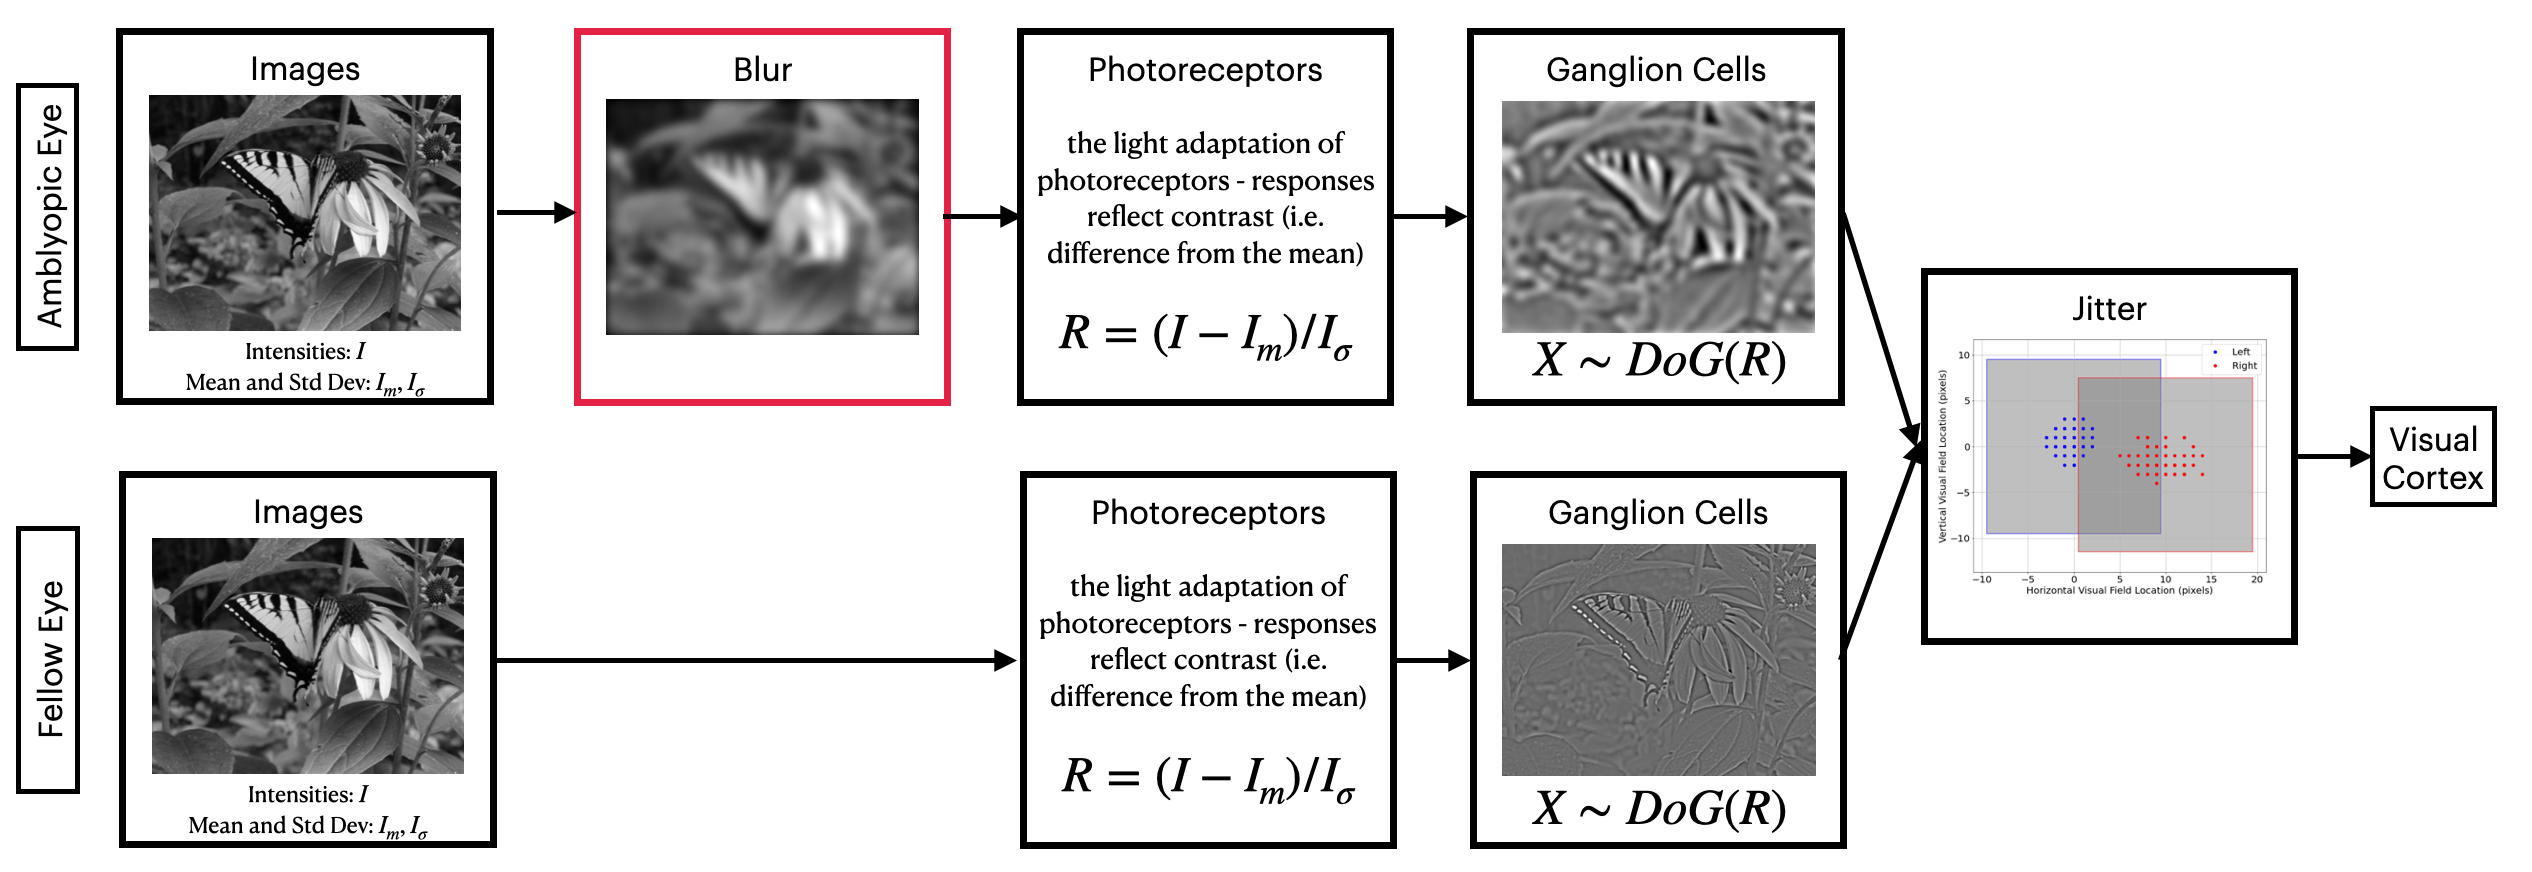

In [5]:
def deficit(blur=[3.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):

    
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


## Continuous Fix

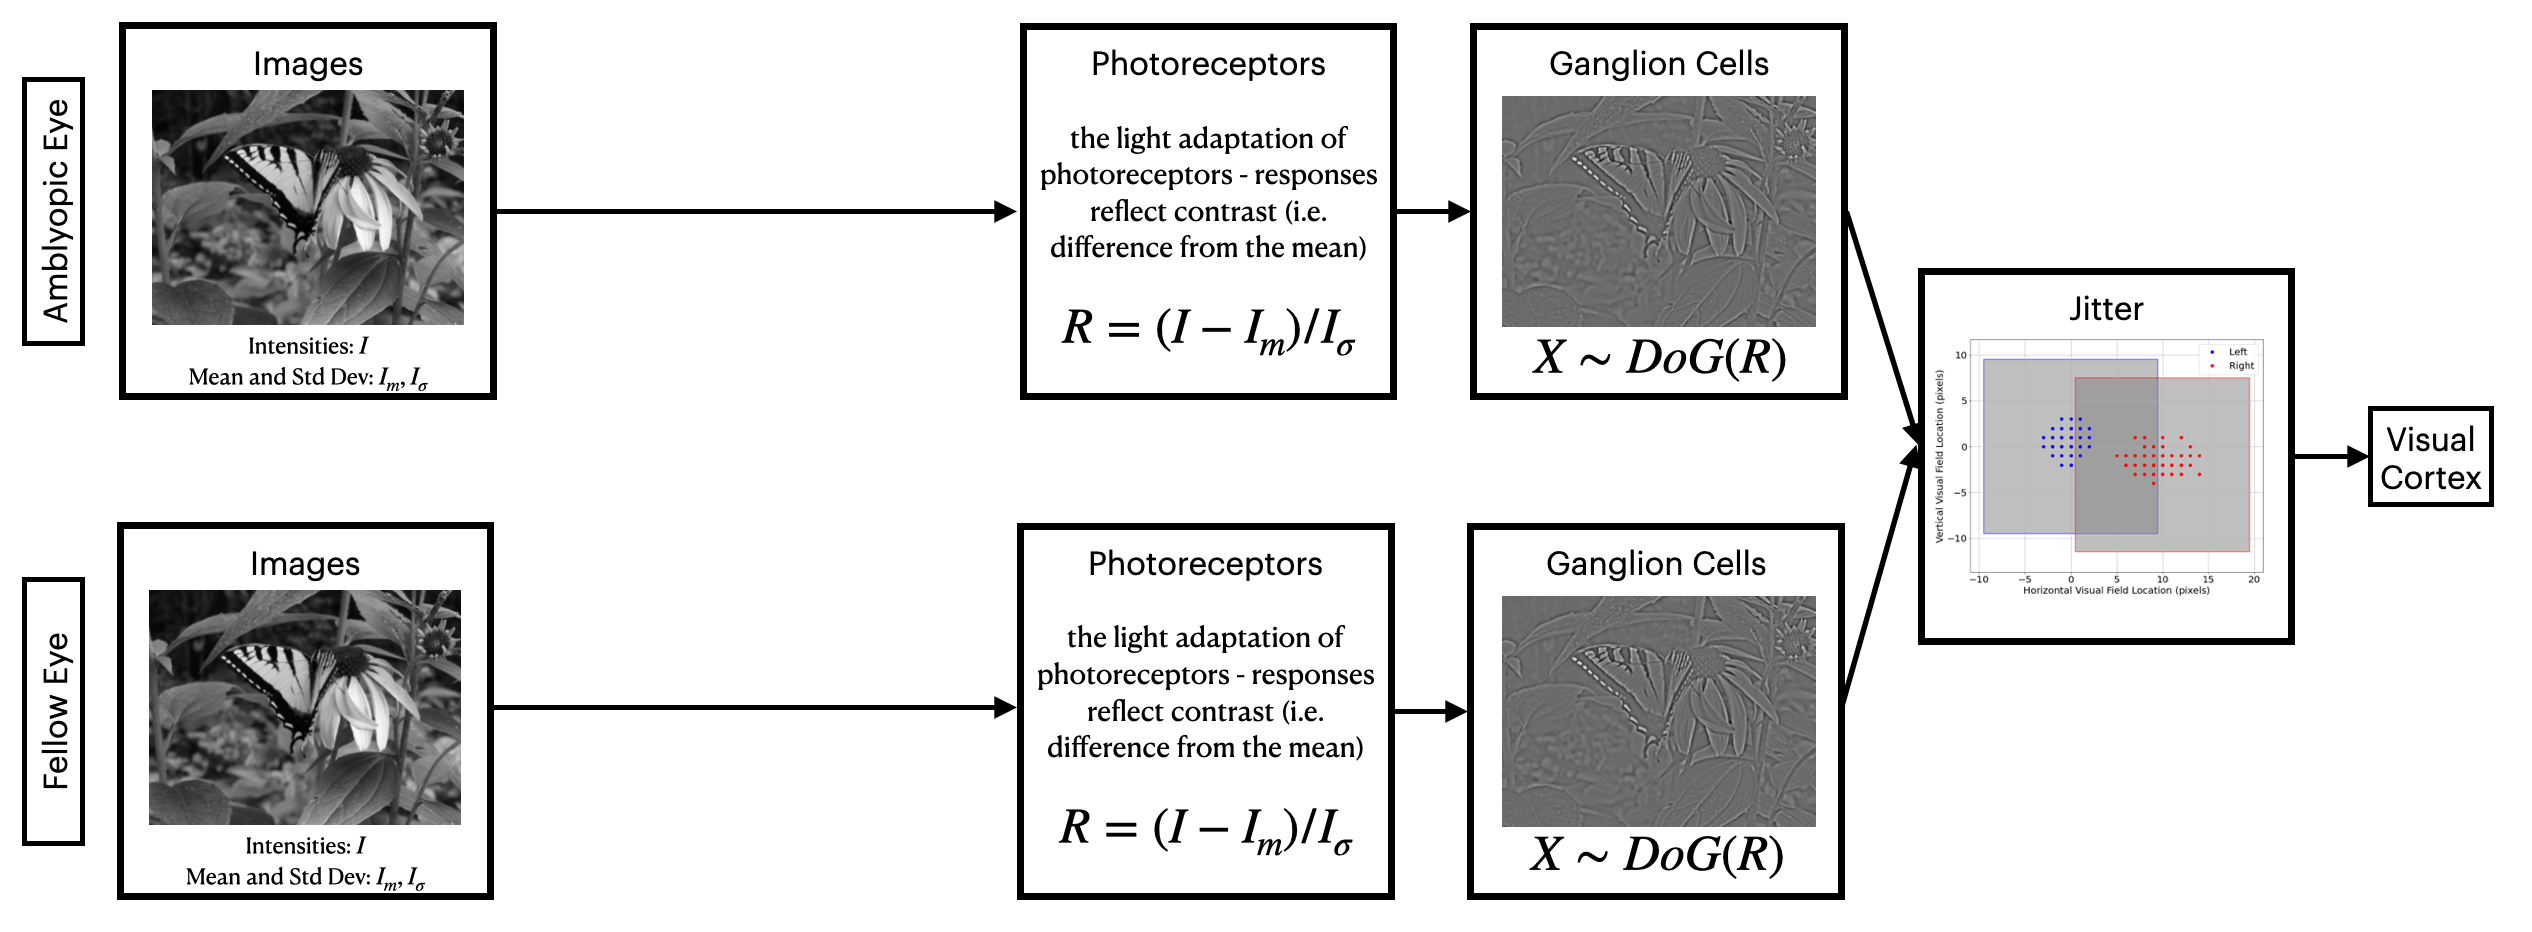

In [6]:
def fix(noise=[0.1,0.1],rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,        
           eta=2e-6):
    
    from numpy import pi
    
    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},
                        verbose=False,
                        )
        ]
                     
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)
    
    


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_fix(params,run=True,overwrite=False):
    import plasticnet as pn
    count,eta,noise,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.count,
                                params.eta,
                                params.noise,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 

    seq+=fix(total_time=100*hour,
             save_interval=20*minute,number_of_neurons=params.number_of_neurons,
             eta=eta,noise=noise,mu_c=mu_c,sigma_c=sigma_c,
             mu_r=mu_r,sigma_r=sigma_r)

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [7]:
number_of_neurons=20
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-04-13 14:48:41,390	INFO worker.py:1852 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.44.1


(pid=24854) Splikes version  0.1.4
(pid=24854) Plasticnet version  0.1.12
(run_one_continuous_patch pid=24854) [
(pid=24855) Splikes version  0.1.4
(pid=24855) Plasticnet version  0.1.12
(run_one_continuous_patch pid=24854) .
(run_one_continuous_patch pid=24853) [ [repeated 7x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=24853) Splikes version  0.1.4 [repeated 6x across cluster]
(pid=24853) Plasticnet version  0.1.12 [repeated 6x across cluster]
(run_one_continuous_patch pid=24854) .] Sequence Time Elapsed...2 m, 42.92 s
(run_one_continuous_patch pid=24856) . [repeated 7x across cluster]
(run_one_continuous_patch pid=24854) [
(run_one_continuous_patch pid=24856) .] Sequence Time Elapsed...2 m, 44.58 s [repeated 7x across cluster]
(run_one_continuous_patch pid=24854) .
(run_one_continuous_patch pid=24

In [8]:
func=run_one_continuous_fix

noise_mat=linspace(0,1,11)

all_params=[]
for n,noise in enumerate(noise_mat):
    sfname=f'{base_sim_dir}/continuous fix {number_of_neurons} neurons noise {noise:.1f}.asdf'
    
    p=Struct()
    p.eta=eta
    p.number_of_neurons=number_of_neurons
    p.sfname=sfname
    p.mu_c=mu_c
    p.sigma_c=sigma_c
    p.mu_r=mu_r
    p.sigma_r=sigma_r
    
    p.noise=(noise,noise)
    
    all_params+=[p]

all_params=to_named_tuple(all_params)  

In [9]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)
    print(sfname)

100%|███████████████████████████████████████████| 11/11 [00:00<00:00, 13.56it/s]

sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.0.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.1.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.2.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.3.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.4.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.5.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.6.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.7.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.8.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.9.asdf
sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 1.0.asdf


In [10]:
do_params=make_do_params(all_params,verbose=True)

Doing 0 sims
Skipping 11 sims
[params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.0.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.0, 0.0), count=0), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.1.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.1), count=1), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.2.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.2, 0.2), count=2), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.3.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.30000000000000004, 0.30000000000000004), count=3), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous fix 20 neurons noise 0.4.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.4, 0.4), count=4), params(

In [11]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [12]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|███████████████████████████████████████████| 11/11 [00:10<00:00,  1.02it/s]


In [13]:
assert func==run_one_continuous_fix
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    noise=params.noise[1]
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)
    
    St+=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2 
        
noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=St.arrays()

glasses_result=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2
savevars(f'{base_sim_dir}/glasses_results.asdf','glasses_result')    

100%|█████████████████████████████████████████| 11/11 [00:00<00:00, 4600.39it/s]

Saving sims-2025-04-07 mu 0 sigma 0/glasses_results.asdf...done.


In [14]:
R.ODI.shape

(494, 20)

In [15]:
glasses_plot_color=cm.viridis(np.linspace(0, 1,5))[2]

Text(0, 0.5, 'ODI')

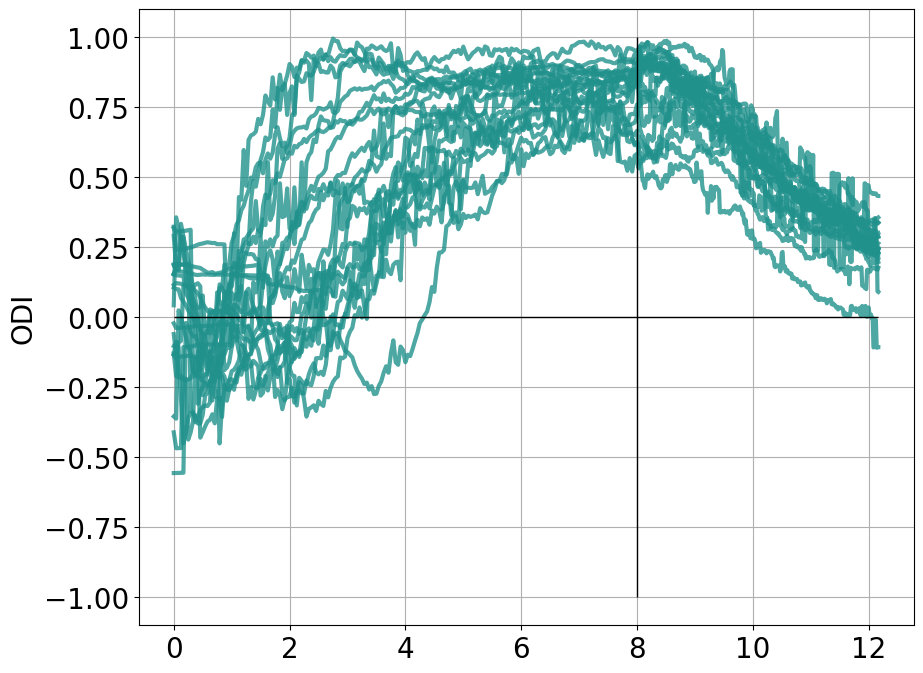

In [16]:
plot(t,R.ODI,'-',color=glasses_plot_color,alpha=0.8);
vlines(t[idx1],-1,1,color='k',lw=1)
hlines(0,t.min(),t.max(),color='k',lw=1)
ylabel('ODI')

Found ['glasses_result']
0.12536254984344986 0.1493926995519692


Text(0.5, 0, 'Open-Eye Noise Level')

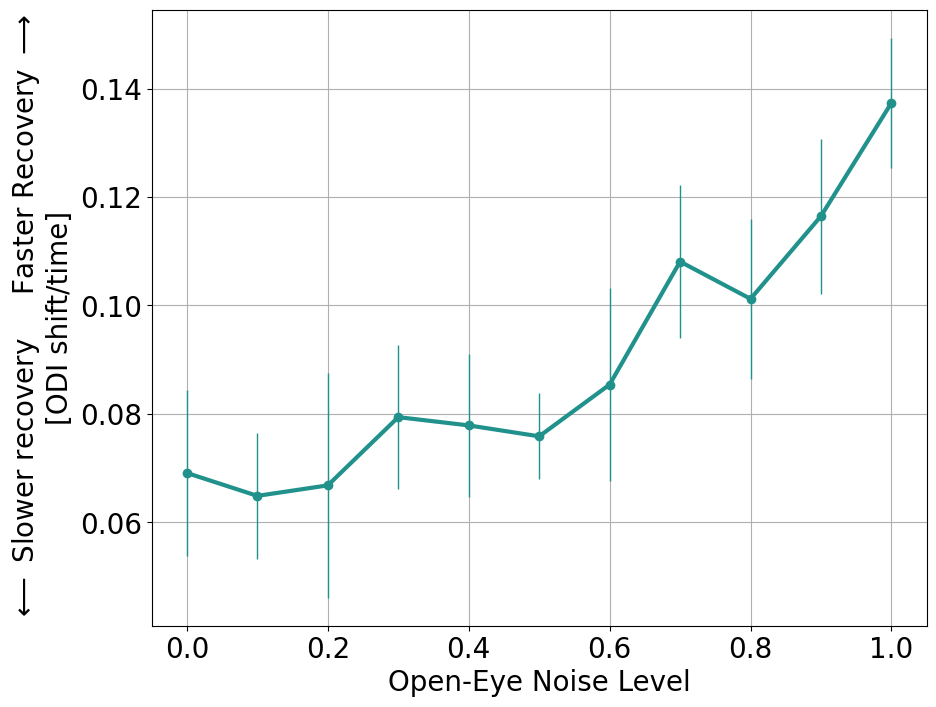

In [29]:
loadvars(f'{base_sim_dir}/glasses_results.asdf')

import cycler
colormap=cm.viridis

n = 5
#colormap=cm.Blues
#color = colormap(np.linspace(1, 0,int(1.2*n)))

colormap=cm.viridis
color = colormap(np.linspace(0, 1,n))

glasses_plot_color=cm.viridis(np.linspace(0, 1,5))[2]

noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=glasses_result        

glasses_μ=-recovery_rate_μ
glasses_σ=2*recovery_rate_σ

# best case
idx=argmax(glasses_μ)
max_glasses=glasses_μ[idx]+glasses_σ[idx]
min_glasses=glasses_μ[idx]-glasses_σ[idx]
print(min_glasses,max_glasses)


errorbar(noise,-recovery_rate_μ,yerr=2*recovery_rate_σ,elinewidth=1,fmt='o-',color=color[2]) # positive = recovery
ylabel(r'$\longleftarrow$ Slower recovery     Faster Recovery $\longrightarrow$'+"\n[ODI shift/time]")
xlabel('Open-Eye Noise Level')
#title('Patch Treatment')

# sfname=f"{savepath}/glasses_treatment.pdf"
# print(sfname)
# savefig(sfname,bbox_inches="tight")


In [17]:
v=linspace(0.3,1,10)
left_deprived_color=Oranges2(v[5])
right_nondeprived_color=Blues2(v[5])

Text(0, 0.5, 'max SF')

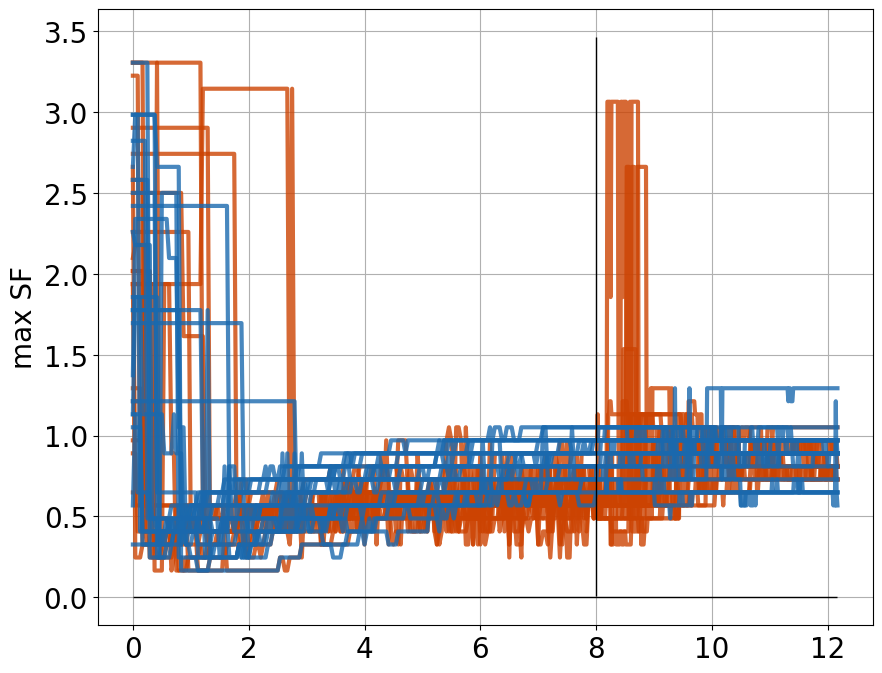

In [18]:
plot(t,R.max_SF[:,:,0],'-',color=left_deprived_color,alpha=0.8);
plot(t,R.max_SF[:,:,1],'-',color=right_nondeprived_color,alpha=0.8);

vlines(t[idx1],*gca().get_ylim(),color='k',lw=1)
hlines(0,t.min(),t.max(),color='k',lw=1)
ylabel('max SF')

Text(0, 0.5, 'SF_Var')

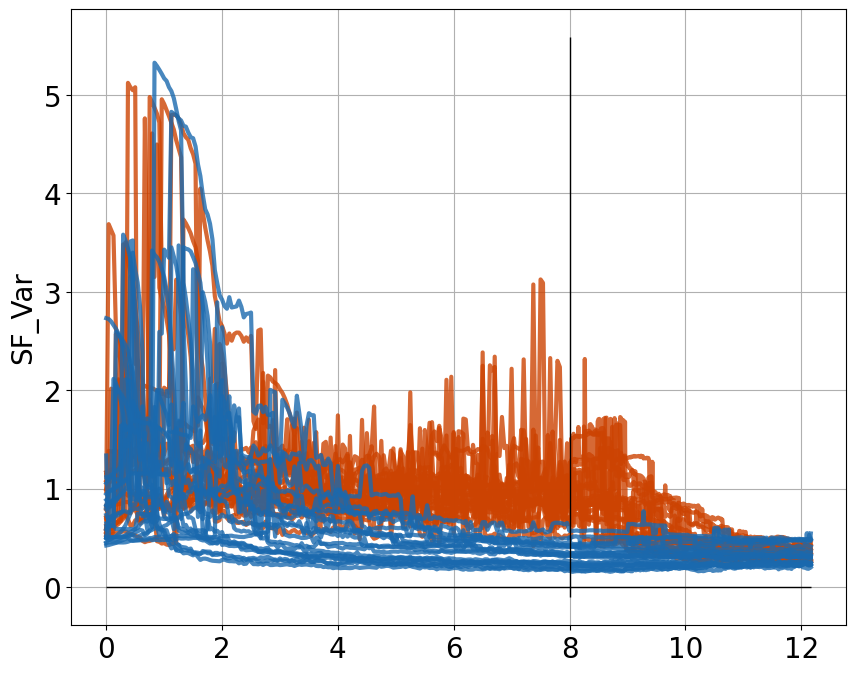

In [19]:
plot(t,R.SF_Var[:,:,0],'-',color=left_deprived_color,alpha=0.8);
plot(t,R.SF_Var[:,:,1],'-',color=right_nondeprived_color,alpha=0.8);

vlines(t[idx1],*gca().get_ylim(),color='k',lw=1)
hlines(0,t.min(),t.max(),color='k',lw=1)
ylabel('SF_Var')

- Do some spatial frequency thing here.
- also check for overcompensation

## Patch treatment

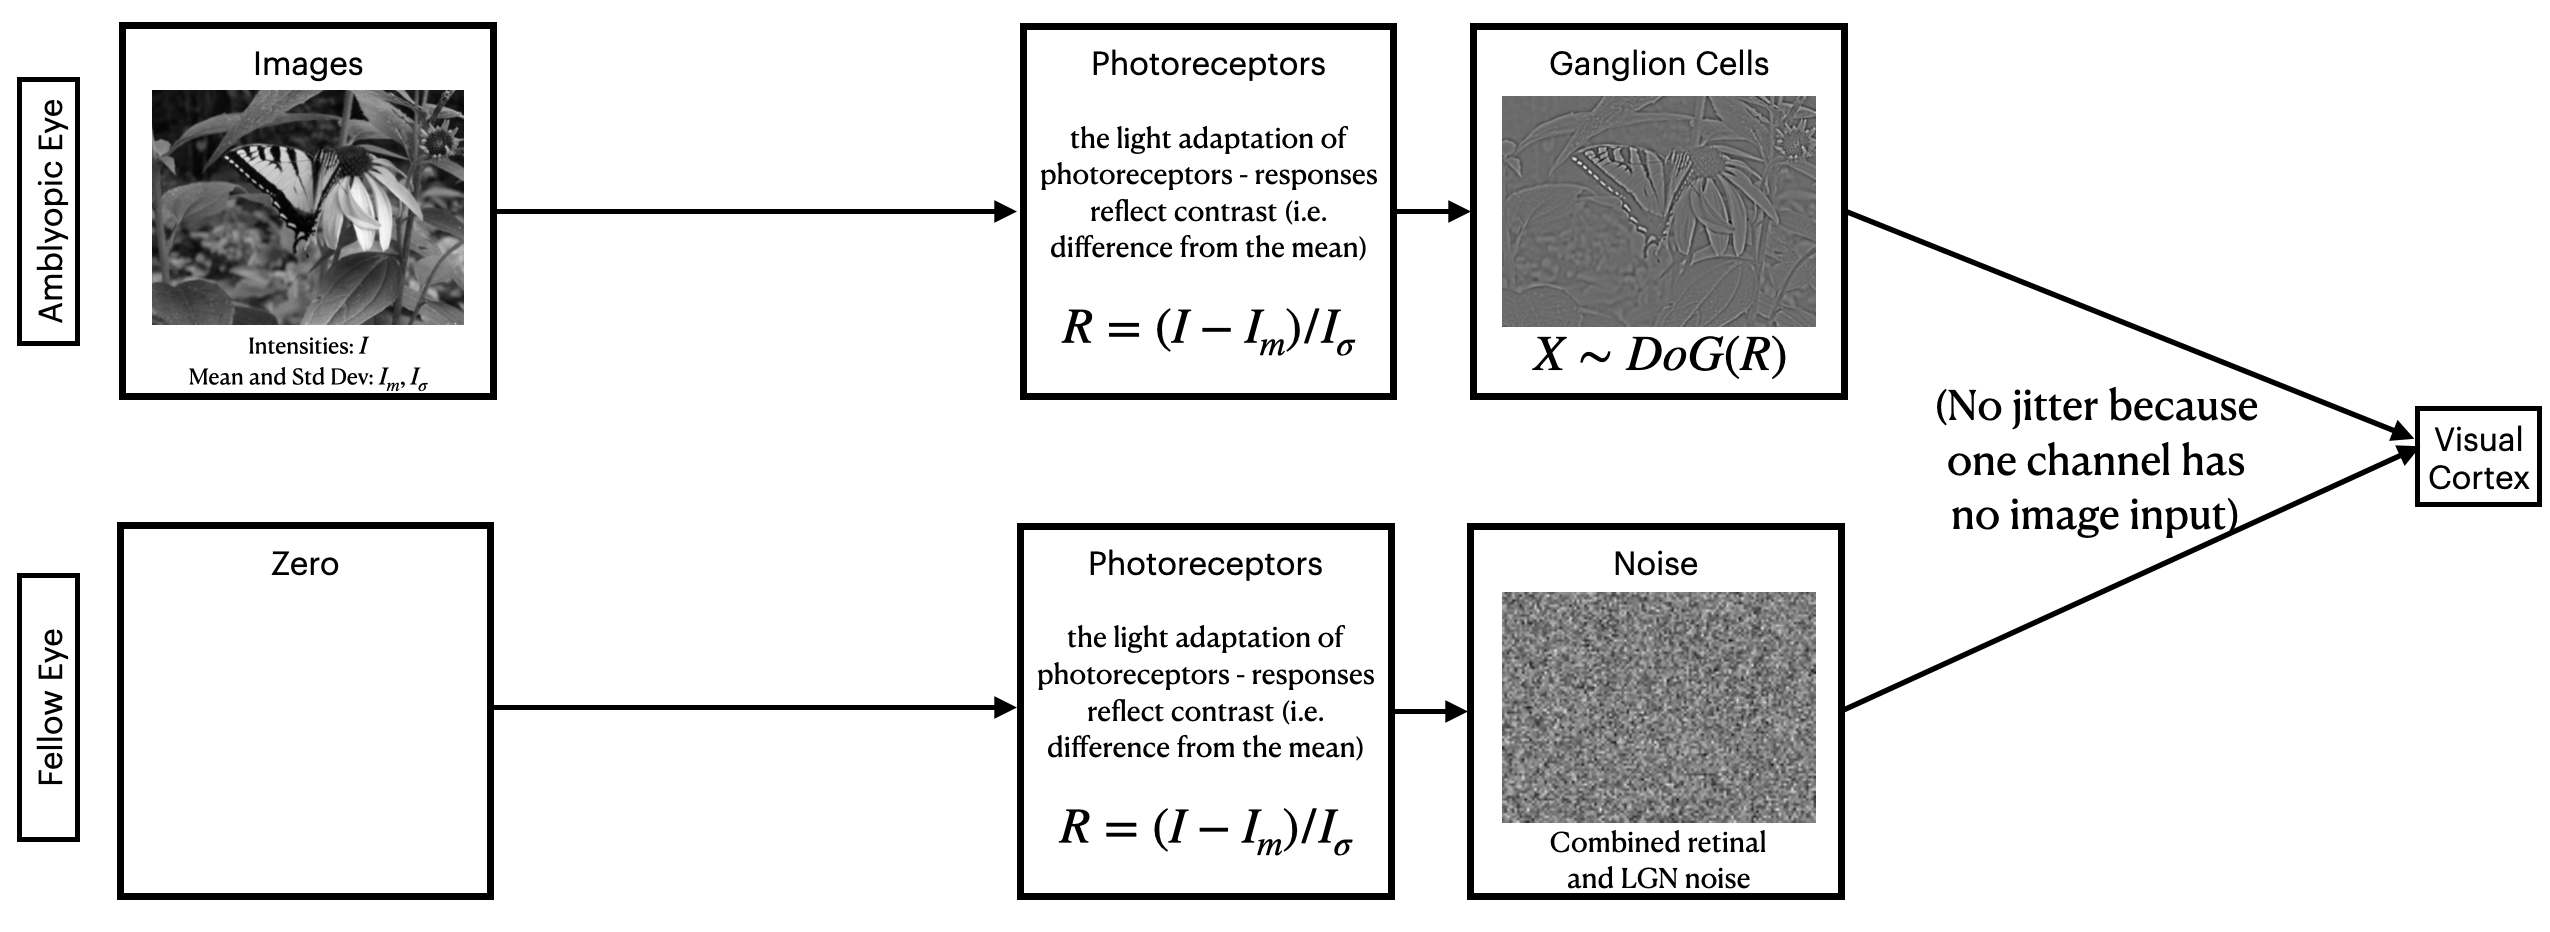

In [20]:
def patch_treatment(noise=[0.1,0.1],rf_size=19,
                   number_of_neurons=20,
                   total_time=8*day,
                   save_interval=1*hour,
                   eta=2e-6,
                    mu_c=0,sigma_c=0,    
                    mu_r=0,sigma_r=0,        
                   ):
    

    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    pre2+=pn.neurons.process.scale_shift(0.0,0) # zero out signal
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_patch(params,run=True,overwrite=False):
    import plasticnet as pn
    count,eta,noise,mu_c,sigma_c,mu_r,sigma_r,number_of_neurons,sfname=(
        params.count,
        params.eta,
        params.noise,
        params.mu_c,
        params.sigma_c,
        params.mu_r,
        params.sigma_r,
        params.number_of_neurons,params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 
    
    seq+=patch_treatment(noise=noise,
               total_time=100*hour,number_of_neurons=params.number_of_neurons,
               eta=eta,
               mu_c=mu_c,sigma_c=sigma_c,
               mu_r=mu_r,sigma_r=sigma_r,
               save_interval=20*minute)

    if run:
        seq.run(display_hash=False,print_time=True)
        pn.save(sfname,seq) 
    
    return sfname
        

In [21]:
func=run_one_continuous_patch

closed_eye_noise_mat=linspace(0,1,21)

all_params=[]
for n,noise in enumerate(closed_eye_noise_mat):
    sfname=f'{base_sim_dir}/continuous patch {number_of_neurons} neurons noise {noise:.1f}.asdf'
    
    p=Struct()
    p.eta=eta
    p.number_of_neurons=number_of_neurons
    p.sfname=sfname
    p.mu_c=mu_c
    p.sigma_c=sigma_c
    p.mu_r=mu_r
    p.sigma_r=sigma_r
    
    p.noise=(0.1,noise)
    
    all_params+=[p]

all_params=to_named_tuple(all_params)  


In [22]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)
    print(sfname)

100%|██████████████████████████████████████████| 21/21 [00:00<00:00, 439.24it/s]

sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.0.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.1.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.1.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.2.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.2.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.2.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.3.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.4.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.4.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.5.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.5.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.6.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.6.asdf
sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0

In [23]:
do_params=make_do_params(all_params,verbose=True)

Doing 21 sims
[params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.0.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.0), count=0), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.1.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.05), count=1), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.1.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.1), count=2), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.2.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.15000000000000002), count=3), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-07 mu 0 sigma 0/continuous patch 20 neurons noise 0.2.asdf', mu_c=0, sigma_c=0, mu_r=0, sigma_r=0, noise=(0.1, 0.2), count=4)] ... [params(eta=1e-06, numbe

In [24]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [25]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|███████████████████████████████████████████| 21/21 [00:22<00:00,  1.08s/it]


In [26]:
assert func==run_one_continuous_patch
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    noise=params.noise[1]
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)
    
    St+=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2 
        
noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=St.arrays()

patch_result=noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2
savevars(f'{base_sim_dir}/patch_results.asdf','patch_result')

100%|█████████████████████████████████████████| 21/21 [00:00<00:00, 2107.39it/s]

Saving sims-2025-04-07 mu 0 sigma 0/patch_results.asdf...done.


Text(0, 0.5, 'ODI')

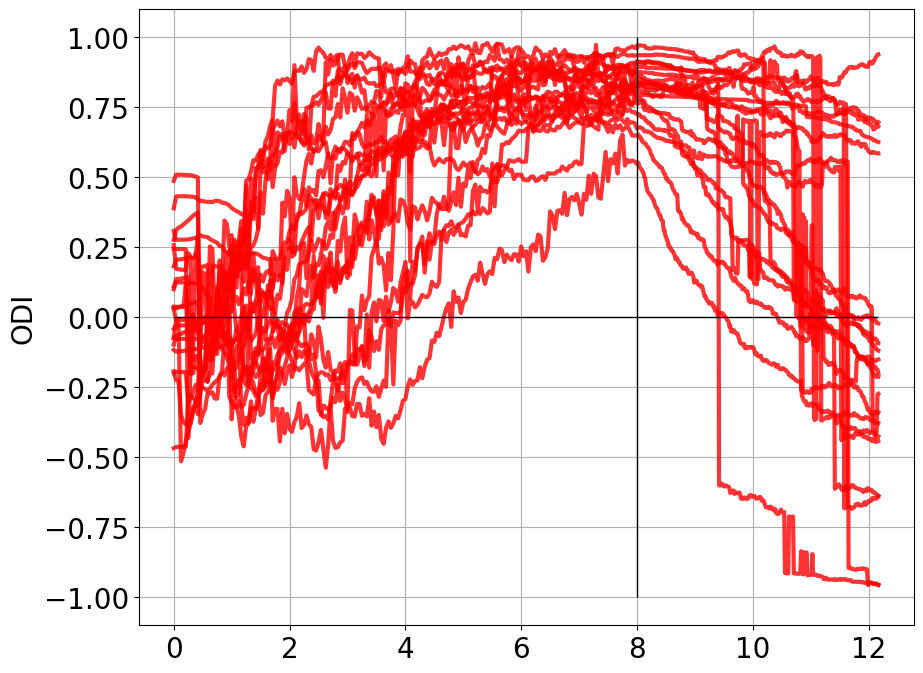

In [27]:
patch_plot_color='red'
plot(t,R.ODI,'-',color=patch_plot_color,alpha=0.8);
vlines(t[idx1],-1,1,color='k',lw=1)
hlines(0,t.min(),t.max(),color='k',lw=1)
ylabel('ODI')

In [38]:
def plot_grb(x,Y):
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    # Create segments for LineCollection
    for y in Y.T:
    
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # Define a custom colormap using RGB interpolation
        def custom_colormap(val):
            """Maps val in [-1, 1] to RGB color (blue → green → red)."""
            val = np.clip(val, -1, 1)
            if val < 0:
                # interpolate between blue and green
                t = (val + 1) / 1  # from 0 (at -1) to 1 (at 0)
                return (0, t, 1)  # blend from blue (0,0,1) to green (0,1,0)
            else:
                # interpolate between green and red
                t = val / 1  # from 0 (at 0) to 1 (at 1)
                return (t, 1 - t, 0)  # blend from green (0,1,0) to red (1,0,0)
        
        # Map each segment's average y-value to a color
        colors = [custom_colormap((y[i] + y[i+1]) / 2) for i in range(len(y)-1)]
        
        # Create line collection
        lc = LineCollection(segments, colors=colors, linewidths=2)
        
        # Plot
        ax=gca()
        ax.add_collection(lc)


Text(0, 0.5, 'ODI')

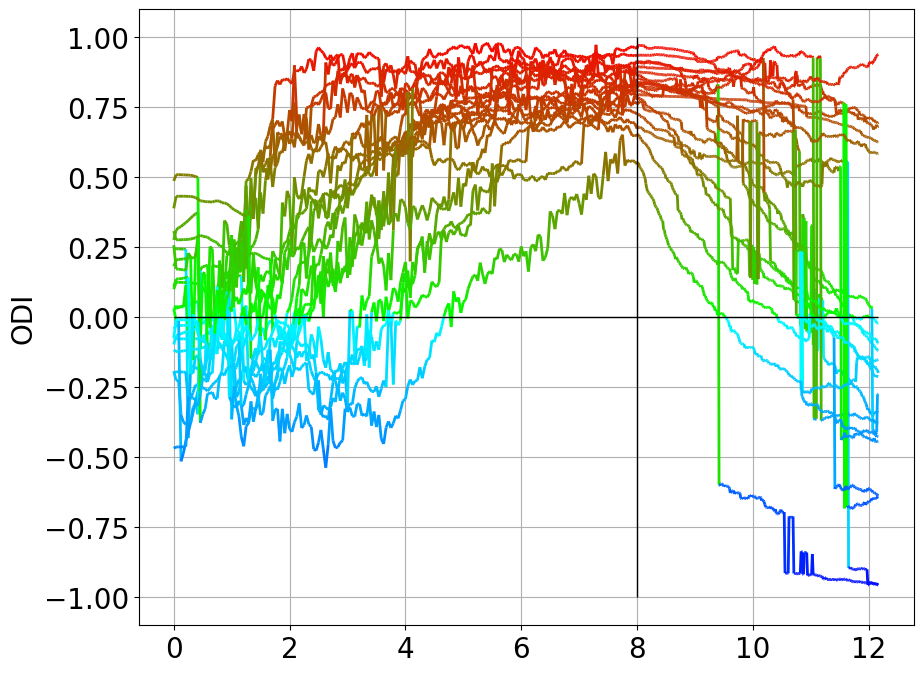

In [39]:
plot_grb(t,R.ODI);
vlines(t[idx1],-1,1,color='k',lw=1)
hlines(0,t.min(),t.max(),color='k',lw=1)
ylabel('ODI')

Found ['patch_result']
0.1638502118715602 0.2822012479936199


Text(0.5, 0, 'Closed-Eye Noise Level')

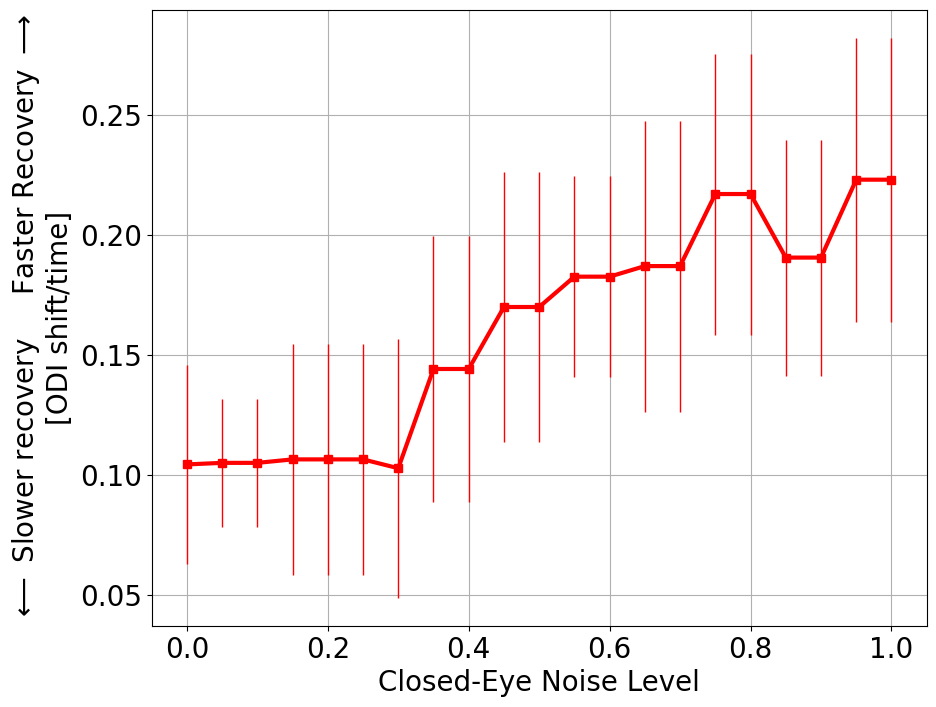

In [30]:
loadvars(f'{base_sim_dir}/patch_results.asdf')

import cycler
colormap=cm.viridis

n = 5
#colormap=cm.Blues
#color = colormap(np.linspace(1, 0,int(1.2*n)))

colormap=cm.viridis
color = colormap(np.linspace(0, 1,n))


noise,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=patch_result        

patch_μ=-recovery_rate_μ
patch_σ=2*recovery_rate_σ

# best case
idx=argmax(patch_μ)
max_patch=patch_μ[idx]+patch_σ[idx]
min_patch=patch_μ[idx]-patch_σ[idx]
print(min_patch,max_patch)


errorbar(noise,-recovery_rate_μ,yerr=2*recovery_rate_σ,elinewidth=1,fmt='rs-') # positive = recovery
ylabel(r'$\longleftarrow$ Slower recovery     Faster Recovery $\longrightarrow$'+"\n[ODI shift/time]")
xlabel('Closed-Eye Noise Level')
#title('Patch Treatment')

# sfname=f"{savepath}/patch_treatment.pdf"
# print(sfname)
# savefig(sfname,bbox_inches="tight")


## TODO

- look at RFs for glasses and patch mid-noise
- look at SF for patch and glasses

## Atropine Treatment

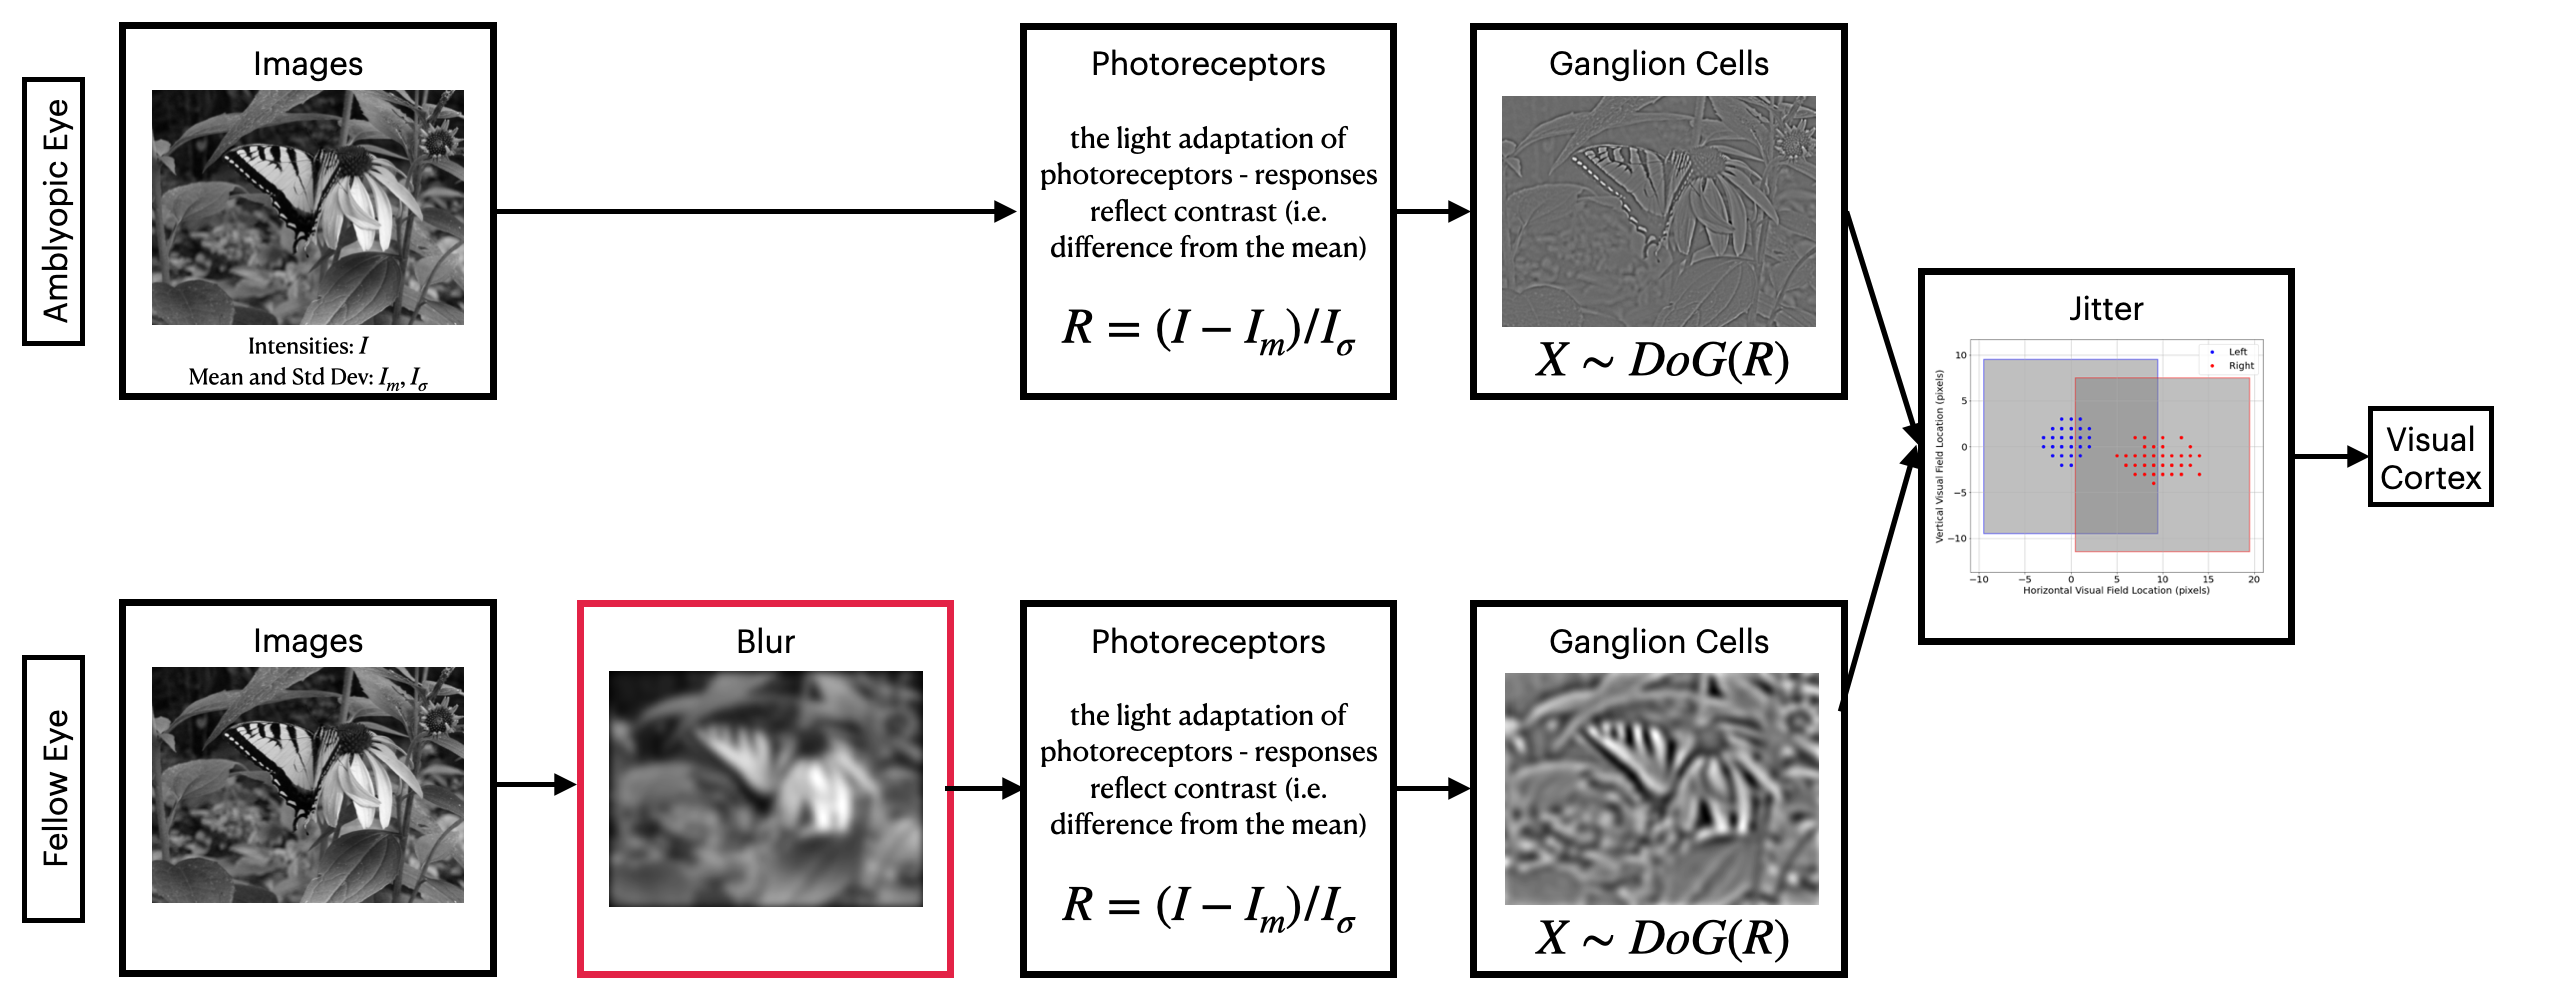

In [22]:
def atropine_treatment(noise=[0.1,0.1],
                       blur=[-1,-1],
                       rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
           eta=2e-6,
                    mu_c=0,sigma_c=0,    
                    mu_r=0,sigma_r=0,        
                      ):
    
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
            
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]




@ray.remote
def run_one_continuous_atropine(params,run=True,overwrite=False):
    import plasticnet as pn
    count,blur,eta,noise,mu_c,sigma_c,mu_r,sigma_r,number_of_neurons,sfname=(
        params.count,
            params.blur,params.eta,params.noise,
        params.mu_c,params.sigma_c,params.mu_r,params.sigma_r,
                params.number_of_neurons,params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 

    seq+=atropine_treatment(blur=(-1,blur),
                   noise=noise,
                   total_time=100*hour,
                    number_of_neurons=params.number_of_neurons,
                   eta=eta,
                   mu_c=mu_c,sigma_c=sigma_c,
                   mu_r=mu_r,sigma_r=sigma_r,
                   save_interval=20*minute)
    

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [23]:
func=run_one_continuous_atropine


atropine_blur_mat=linspace(0,6,21)
closed_eye_noise_mat=linspace(0,1,11)

all_params=[]
for b,blur in enumerate(atropine_blur_mat):
    for n,noise in enumerate(closed_eye_noise_mat):
        sfname=f'{base_sim_dir}/continuous atropine {number_of_neurons} neurons noise {noise:.1f} blur {blur:0.1f}.asdf'

        p=Struct()
        p.eta=eta
        p.number_of_neurons=number_of_neurons
        p.sfname=sfname
        p.mu_c=mu_c
        p.sigma_c=sigma_c
        p.mu_r=mu_r
        p.sigma_r=sigma_r

        p.noise=(0.1,noise)
        p.blur=blur

        all_params+=[p]

all_params=to_named_tuple(all_params)  

In [24]:
do_params=make_do_params(all_params,verbose=True)

Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.0 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.1 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.2 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.3 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.4 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.5 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.6 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.7 blur 0.0.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous atropine 20 neurons noise 0.8 blur 0.0.asdf...already exists
Skipping s

In [25]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)

100%|████████████████████████████████████████| 231/231 [00:00<00:00, 822.30it/s]


In [26]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [27]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|█████████████████████████████████████████| 231/231 [03:48<00:00,  1.01it/s]


In [28]:
assert func==run_one_continuous_atropine
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    noise=params.noise[1]
    blur=params.blur
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)
    
    St+=noise,blur,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2 
        
noise,blur,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=St.arrays()

100%|███████████████████████████████████████| 231/231 [00:00<00:00, 1530.86it/s]


In [29]:
blur_orig=blur
noise_orig=noise

In [30]:
noise_N=len(closed_eye_noise_mat)
blur_N=len(atropine_blur_mat)

noise=noise.reshape(blur_N,noise_N)
noise,blur,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=[
    _.reshape(blur_N,noise_N).T for _ in 
        (noise,blur,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2)]

In [31]:
blur

array([[0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. ],
       [0. , 0.3, 0.6, 0

In [32]:
atropine_result=noise,blur,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2

savevars(f'{base_sim_dir}/atropine_results.asdf','atropine_result')

Saving sims-2025-02-25 mu 0 sigma 0/atropine_results.asdf...done.


## Contrast, then Contrast with Mask

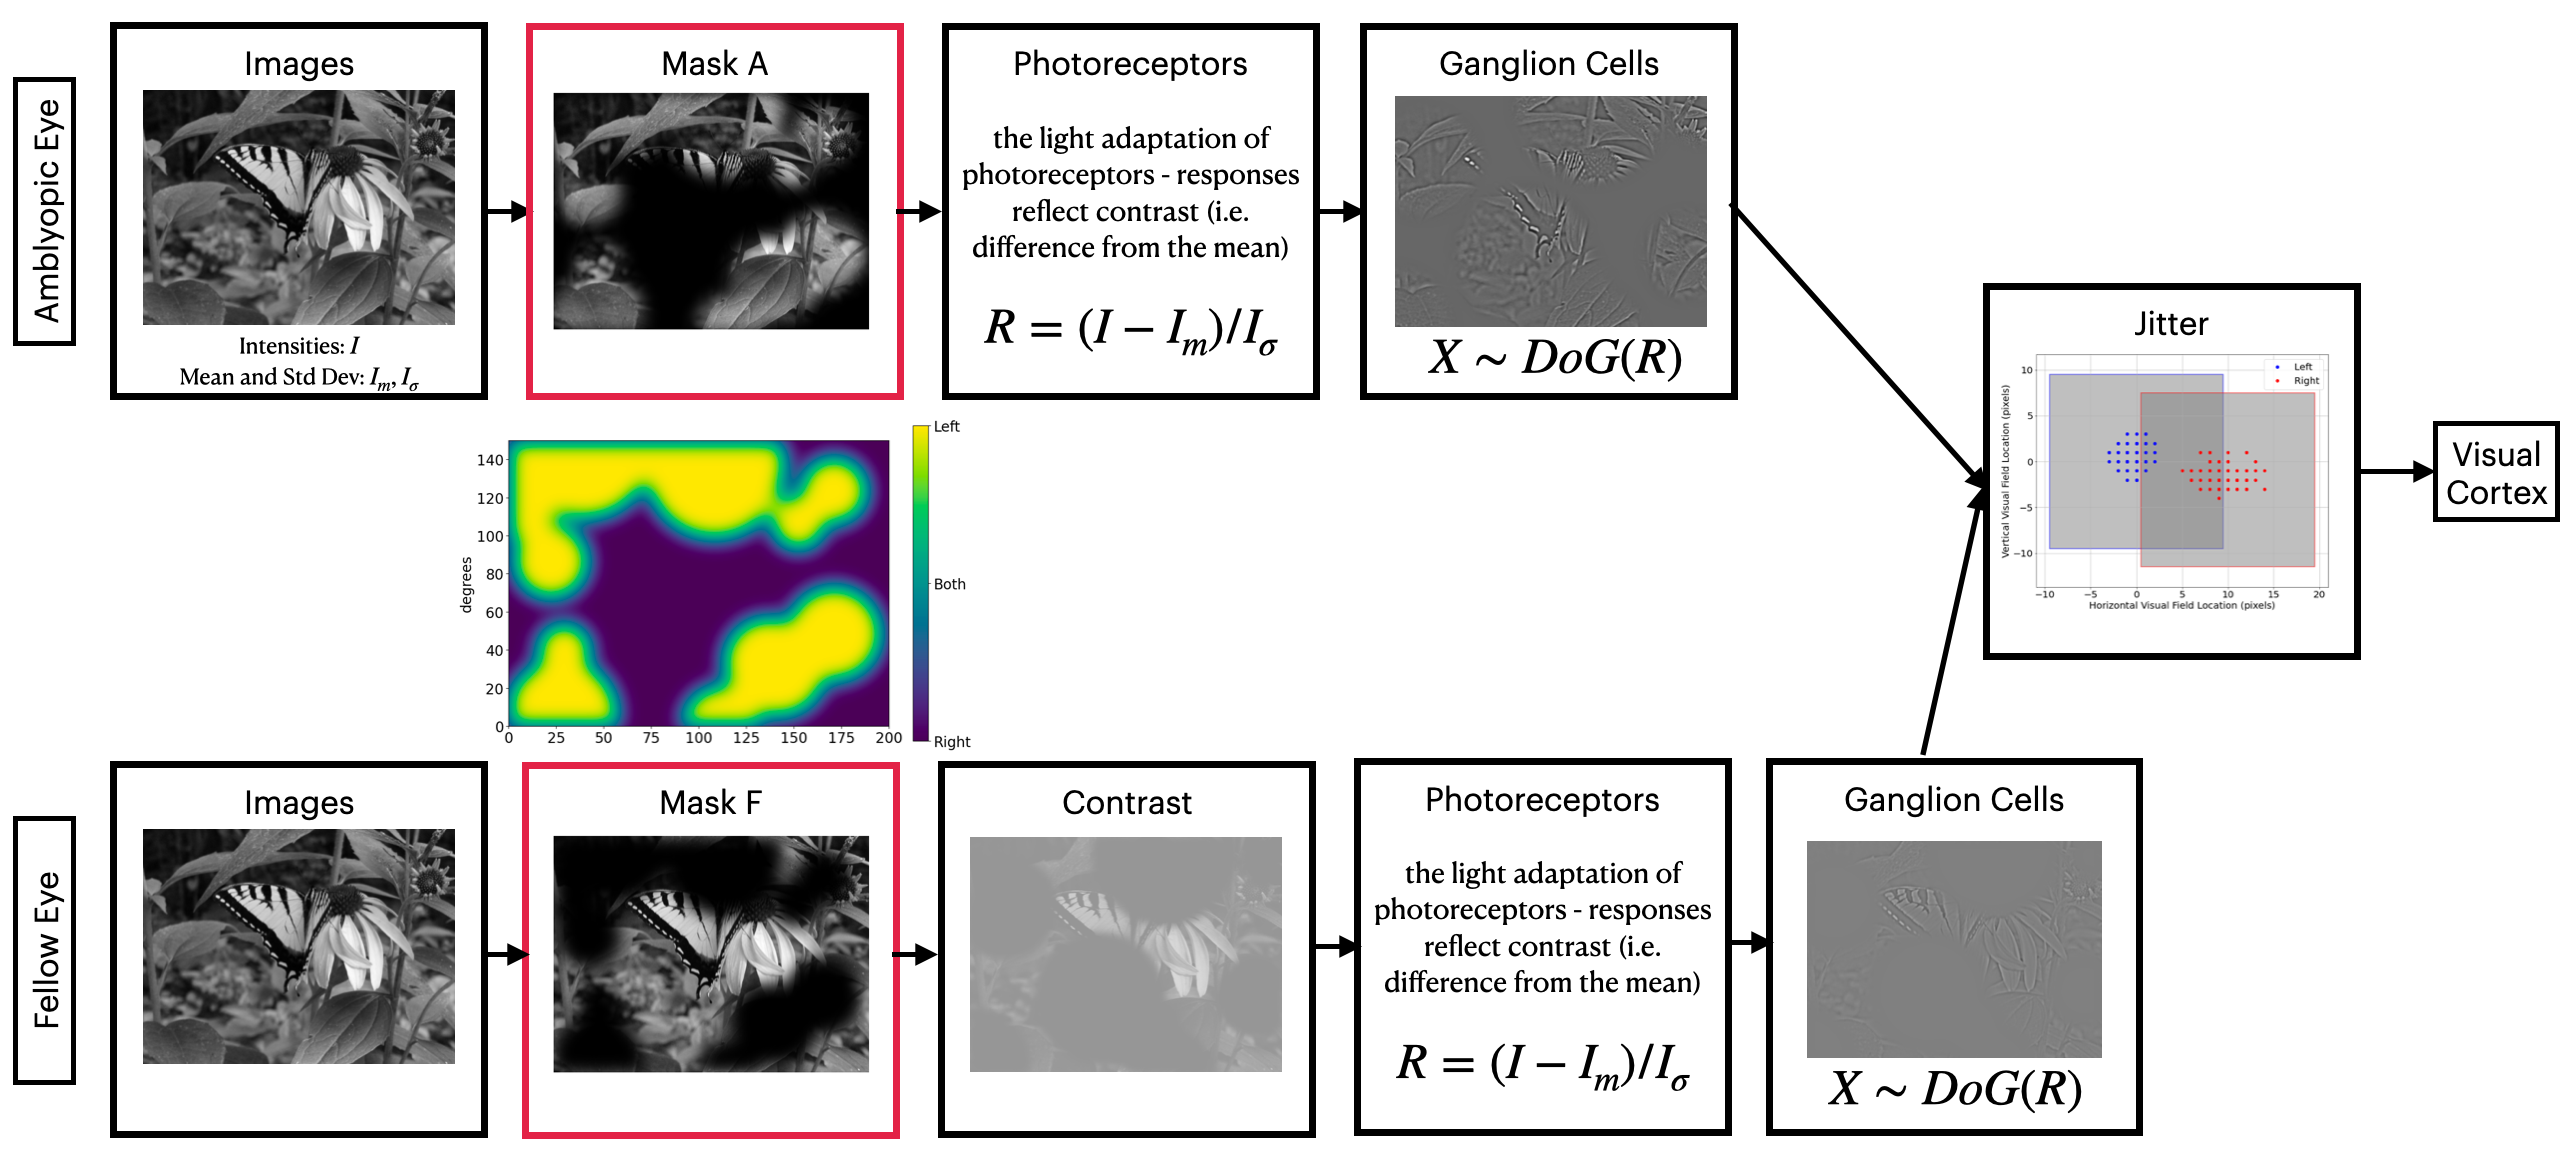

In [33]:
def mask_contrast_treatment(contrast=[1,1],noise=[0.1,0.1],
              rf_size=19,eta=5e-6,
                    mu_c=0,sigma_c=0,    
                    mu_r=0,sigma_r=0,        
              f=30,  # size of the blur for mask, which is a measure of overlap
           number_of_neurons=20,
           total_time=8*day,
           save_interval=1*hour,
             mask=None,
             blur=(-1,-1)):
    
    
    if not f in [10,30,50,70,90]:
        raise ValueError("Unknown f %s" % str(f))

        
        
    im=[]
    if not mask:
        for (b,c) in zip(blur,contrast):
            if b<0:
                im+=[pi5.filtered_images(base_image_file,
                                        {'type':'mask',
                                         'name':'', 
                                        'seed':101,'apply_to_average':True},
                                        {'type':'norm'},
                                        {'type':'dog','sd1':1,'sd2':3},   
                                        verbose=False,
                                        )
                    ]
            else:
                im+=[pi5.filtered_images(base_image_file,
                                        {'type':'mask',
                                         'name':'', 
                                        'seed':101,'apply_to_average':True},
                                        {'type':'blur','size':b},
                                        {'type':'norm'},
                                        {'type':'dog','sd1':1,'sd2':3},   
                                        verbose=False,
                                        )
                    ]
    else:
        for [b,mask_name,c] in zip(blur,['A','F'],contrast):
            if b<0:
                im+=[pi5.filtered_images(base_image_file,
                                        {'type':'mask',
                                         'name':f'bblais-masks-20240511/2024-05-11-*-{mask_name}-fsig{int(f)}.png', 
                                        'seed':101,'apply_to_average':True},
                                        {'type':'norm'},
                                        {'type':'dog','sd1':1,'sd2':3},   
                                        verbose=False,
                                         )
                    ]
            else:
                im+=[pi5.filtered_images(base_image_file,
                                        {'type':'mask',
                                         'name':f'bblais-masks-20240511/2024-05-11-*-{mask_name}-fsig{int(f)}.png', 
                                        'seed':101,'apply_to_average':True},
                                        {'type':'blur','size':b},
                                        {'type':'norm'},
                                        {'type':'dog','sd1':1,'sd2':3},   
                                        verbose=False,
                                        )
                     ]
        
        
        
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)

    if contrast[0]!=1:
        pre1+=pn.neurons.process.scale_shift(contrast[0],0)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    
    if contrast[1]!=1:
        pre2+=pn.neurons.process.scale_shift(contrast[1],0)
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(-1,50)

    c=pn.connections.BCM(pre,post,[-.1,.1],[.1,.2])
    c.eta=eta
    c.tau=100*second

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]


    

@ray.remote
def run_one_continuous_mask(params,run=True,overwrite=False):
    import plasticnet as pn
    count,eta,contrast,mask,f,mu_c,sigma_c,mu_r,sigma_r,number_of_neurons,sfname=(
        params.count,params.eta,params.contrast,params.mask,params.f,
        params.mu_c,params.sigma_c,params.mu_r,params.sigma_r,
        params.number_of_neurons,params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname

    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,
                )

    seq+=mask_contrast_treatment(f=f,
                   mask=mask,
                   contrast=contrast,
                   total_time=100*hour,
                   eta=eta,
                mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,
                   save_interval=20*minute)

    if run:
        seq.run(display_hash=False,print_time=True)
        pn.save(sfname,seq) 

    
    return sfname
    
    

In [34]:
func=run_one_continuous_mask


contrast_mat=linspace(0,1,21)
f_mat=array([10,30,50,70,90])


all_params=[]
for c,contrast in enumerate(contrast_mat):
    sfname=f'{base_sim_dir}/continuous contrast {number_of_neurons} neurons contrast {contrast:.2f}.asdf'

    p=Struct()
    p.eta=eta
    p.number_of_neurons=number_of_neurons
    p.sfname=sfname

    p.contrast=(1,contrast)
    p.mask=0
    p.f=10. # not used when mask=0
    p.mu_c=mu_c
    p.sigma_c=sigma_c
    p.mu_r=mu_r
    p.sigma_r=sigma_r

    all_params+=[p]

all_params=to_named_tuple(all_params)  

In [35]:
do_params=make_do_params(all_params,verbose=True)

Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.05.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.10.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.15.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.20.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.25.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.30.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.35.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.40.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contra

In [36]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)

100%|██████████████████████████████████████████| 21/21 [00:00<00:00, 575.38it/s]


In [37]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [38]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|███████████████████████████████████████████| 21/21 [00:20<00:00,  1.02it/s]


In [39]:
assert func==run_one_continuous_mask
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    contrast=params.contrast[1]
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)
    
    St+=contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2 
        
contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=St.arrays()

contrast_result=contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2

savevars(f'{base_sim_dir}/contrast_results.asdf','contrast_result')

100%|█████████████████████████████████████████| 21/21 [00:00<00:00, 3154.63it/s]

Saving sims-2025-02-25 mu 0 sigma 0/contrast_results.asdf...done.


## Contrast with Mask

In [40]:
func=run_one_continuous_mask


contrast_mat=linspace(0,1,21)
f_mat=array([10,30,50,70,90])

all_params=[]
for c,contrast in enumerate(contrast_mat):
    for fi,f in enumerate(f_mat):
    
        sfname=f'{base_sim_dir}/continuous contrast {number_of_neurons} neurons contrast {contrast:.2f} mask f {f}.asdf'

        p=Struct()
        p.eta=eta
        p.number_of_neurons=number_of_neurons
        p.sfname=sfname

        p.contrast=(1,contrast)
        p.mask=1
        p.f=f
        p.mu_c=mu_c
        p.sigma_c=sigma_c
        p.mu_r=mu_r
        p.sigma_r=sigma_r

        all_params+=[p]

all_params=to_named_tuple(all_params)  



In [41]:
do_params=make_do_params(all_params,verbose=True)

Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00 mask f 10.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00 mask f 30.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00 mask f 50.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00 mask f 70.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.00 mask f 90.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.05 mask f 10.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.05 mask f 30.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.05 mask f 50.asdf...already exists
Skipping sims-2025-02-25 mu 0 sigma 0/continuous contrast 20 neurons contrast 0.

In [42]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)

100%|████████████████████████████████████████| 105/105 [00:00<00:00, 863.13it/s]


In [43]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [44]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|█████████████████████████████████████████| 105/105 [01:42<00:00,  1.02it/s]


In [45]:
assert func==run_one_continuous_mask
St=Storage()
for params in tqdm(all_params):
    sfname=params.sfname
    contrast=params.contrast[1]
    f=params.f
    
    R=RR[sfname]

    
    idx1,idx2=[_[1] for _ in R.sequence_index]
    t=R.t/day
    recovery_rate_μ,recovery_rate_σ=μσ((R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1]))  

    ODI_μ2=R.ODI[idx2,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx2,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ2=K*S/np.sqrt(N)

    ODI_μ1=R.ODI[idx1,:].mean()  # average across neurons, at the end of a seq, for each channel
    S=R.ODI[idx1,:].std()
    N=R.ODI.shape[1]
    K=1+20/N**2
    ODI_σ1=K*S/np.sqrt(N)
    
    St+=f,contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2 
        
f,contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=St.arrays()

100%|███████████████████████████████████████| 105/105 [00:00<00:00, 5661.28it/s]


In [46]:
f_N=len(f_mat)
contrast_N=len(contrast_mat)

contrast.reshape(contrast_N,f_N)

array([[0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, 0.05, 0.05],
       [0.1 , 0.1 , 0.1 , 0.1 , 0.1 ],
       [0.15, 0.15, 0.15, 0.15, 0.15],
       [0.2 , 0.2 , 0.2 , 0.2 , 0.2 ],
       [0.25, 0.25, 0.25, 0.25, 0.25],
       [0.3 , 0.3 , 0.3 , 0.3 , 0.3 ],
       [0.35, 0.35, 0.35, 0.35, 0.35],
       [0.4 , 0.4 , 0.4 , 0.4 , 0.4 ],
       [0.45, 0.45, 0.45, 0.45, 0.45],
       [0.5 , 0.5 , 0.5 , 0.5 , 0.5 ],
       [0.55, 0.55, 0.55, 0.55, 0.55],
       [0.6 , 0.6 , 0.6 , 0.6 , 0.6 ],
       [0.65, 0.65, 0.65, 0.65, 0.65],
       [0.7 , 0.7 , 0.7 , 0.7 , 0.7 ],
       [0.75, 0.75, 0.75, 0.75, 0.75],
       [0.8 , 0.8 , 0.8 , 0.8 , 0.8 ],
       [0.85, 0.85, 0.85, 0.85, 0.85],
       [0.9 , 0.9 , 0.9 , 0.9 , 0.9 ],
       [0.95, 0.95, 0.95, 0.95, 0.95],
       [1.  , 1.  , 1.  , 1.  , 1.  ]])

In [47]:
f_N=len(f_mat)
contrast_N=len(contrast_mat)


f,contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2=[
    _.reshape(contrast_N,f_N).T for _ in 
        (f,contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2)]

In [48]:

mask_result=f,contrast,recovery_rate_μ,recovery_rate_σ,ODI_μ1,ODI_σ1,ODI_μ2,ODI_σ2

savevars(f'{base_sim_dir}/mask_results.asdf','mask_result')

Saving sims-2025-02-25 mu 0 sigma 0/mask_results.asdf...done.
